# Audrey - Building a Speech Recognition System

In 1952, Bell Labs created **AUDREY** (Automatic Digit Recognition), the first speech recognition system. It could recognize spoken digits 0-9 with ~90% accuracy - but only for a single speaker!

In this notebook, we'll build our own version of Audrey using modern deep learning. Along the way, you'll learn:

- **Data Collection**: Recording your own speech dataset
- **Data Augmentation**: Creating variations to make your model more robust  
- **Neural Networks**: Training both simple (MLP) and convolutional (CNN) models
- **Inference**: Using your trained model for real-time digit recognition

**Key Concept**: Machine learning models learn patterns from data. The more varied and representative your training data, the better your model will generalize to new inputs.

## Part 1: Recording Your Dataset

Every machine learning project starts with **data**. We need examples of what we want our model to recognize.

For speech recognition, we need audio recordings of each digit (0-9). You'll record yourself saying each digit, creating 10 audio files that will form the basis of our training data.

**Why record yourself?** Like the original Audrey, our model will be "speaker-dependent" - trained on your voice. This makes the problem easier to solve with limited data.

In [1]:
# Let's create our own speech dataset! This work with numbers first

# Recording audio with sounddevice and soundfile
# 
# https://python-soundfile.readthedocs.io/
# https://python-sounddevice.readthedocs.io


import sounddevice as sd
import soundfile as sf
import numpy as np
import time

def record_audio(filename: str, duration: int):

    # config
    samplerate = 44100
    duration = duration
    channels = 1

    print(f"Recording for {duration} seconds at {samplerate} Hz...")

    # record audio from the microphone into a numpy array with sounddevice
    recording = sd.rec(
        int(duration * samplerate),
        samplerate=samplerate,
        channels=channels,
        dtype='float32'
    )
    sd.wait()

    print(f"Recording finished. Saving to {filename}...")

    # save the file with soundfile
    sf.write(
        filename,
        recording,
        samplerate,
        subtype='PCM_16'
        )

    print(f"File '{filename}' saved successfully.")

In [13]:
# record yourself saying the digits 0-9

record_audio(
    filename='unprocessed/9.wav', # rename the file to 1.wav, 2.wav, 3.wav, etc.
    duration=2)

Recording for 2 seconds at 44100 Hz...
Recording finished. Saving to unprocessed/9.wav...
File 'unprocessed/9.wav' saved successfully.


## Part 2: Data Augmentation

We only have 10 recordings, but neural networks typically need thousands of examples to learn well. 

**Data augmentation** solves this by creating variations of our original data:
- **Noise**: Adding random background noise (simulates different environments)
- **Time Stretch**: Making audio faster/slower (simulates speaking pace variation)
- **Pitch Shift**: Raising/lowering pitch (simulates voice variation)
- **Time Shift**: Moving audio left/right (simulates different recording starts)

From 10 original recordings, we'll create **10,000 augmented samples** (1,000 variations per digit)!

In [15]:
# Data augmentation functions - each creates a different variation of the audio

import numpy as np
import librosa

def noise(data, noise_amt=0.035):
    """Add random background noise to simulate different recording environments"""
    noise_amp = noise_amt * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    """Speed up or slow down the audio (rate < 1 = slower, rate > 1 = faster)"""
    return librosa.effects.time_stretch(data, rate=rate)

def shift(data):
    """Shift audio left or right in time (simulates different recording starts)"""
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, n_steps=2):
    """Shift pitch up or down (n_steps = semitones, + = higher, - = lower)"""
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

In [16]:
# take our recorded digits, and augment them to create a larger dataset

import os
import glob
import subprocess
import librosa
import numpy as np
import soundfile as sf
from tqdm.notebook import tqdm

# get all files in the 'unprocessed' directory (only .wav files)
files = glob.glob('unprocessed/*.wav')
print(files)

for file in tqdm(files):
    # get the digit from the file name
    digit = file.split('/')[-1].split('.')[0]
    
    # create the directory if it doesn't exist
    os.makedirs(f'processed/{digit}', exist_ok=True)
    # load file with sf
    audio, sample_rate = sf.read(file)

    for i in tqdm(range(1000)):
        
        processed_audio = noise(audio, np.random.uniform(0.001, 0.01))
        processed_audio = stretch(processed_audio, rate=np.random.uniform(0.8, 1.2))
        processed_audio = shift(processed_audio)
        processed_audio = pitch(processed_audio, sample_rate, n_steps=np.random.randint(-3, 3))

        sf.write(f'processed/{digit}/{digit}_{i}.wav', processed_audio, sample_rate)

['unprocessed/9.wav', 'unprocessed/8.wav', 'unprocessed/6.wav', 'unprocessed/7.wav', 'unprocessed/5.wav', 'unprocessed/4.wav', 'unprocessed/0.wav', 'unprocessed/1.wav', 'unprocessed/3.wav', 'unprocessed/2.wav']


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/numba/cpython/hashing.py:477: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [18]:
# get all of the fies in speech_digits with glob
import glob

files = glob.glob('processed/*/*')

print(len(files))
print(files[:5])


10000
['processed/9/9_448.wav', 'processed/9/9_306.wav', 'processed/9/9_460.wav', 'processed/9/9_474.wav', 'processed/9/9_312.wav']


## Part 3: Data Preprocessing

Before training, we need to prepare our data:

1. **Consistent Length**: Neural networks expect fixed-size inputs. We'll pad shorter audio files to match the longest one.

2. **Labels**: Each file needs a label (0-9) so the model knows what it should predict.

3. **Verification**: Check that all files are the same length after processing.

**Why padding?** Think of it like standardizing paper sizes before putting them in a binder - everything needs to fit the same format.

['processed/9/9_448.wav', 'processed/9/9_306.wav', 'processed/9/9_460.wav', 'processed/9/9_474.wav', 'processed/9/9_312.wav', 'processed/9/9_886.wav', 'processed/9/9_138.wav', 'processed/9/9_49.wav', 'processed/9/9_892.wav', 'processed/9/9_662.wav', 'processed/9/9_61.wav', 'processed/9/9_104.wav', 'processed/9/9_75.wav', 'processed/9/9_110.wav', 'processed/9/9_676.wav', 'processed/9/9_845.wav', 'processed/9/9_689.wav', 'processed/9/9_851.wav', 'processed/9/9_879.wav', 'processed/9/9_716.wav', 'processed/9/9_702.wav', 'processed/9/9_931.wav', 'processed/9/9_925.wav', 'processed/9/9_919.wav', 'processed/9/9_528.wav', 'processed/9/9_1.wav', 'processed/9/9_272.wav', 'processed/9/9_514.wav', 'processed/9/9_500.wav', 'processed/9/9_266.wav', 'processed/9/9_299.wav', 'processed/9/9_298.wav', 'processed/9/9_501.wav', 'processed/9/9_267.wav', 'processed/9/9_273.wav', 'processed/9/9_515.wav', 'processed/9/9_0.wav', 'processed/9/9_529.wav', 'processed/9/9_918.wav', 'processed/9/9_924.wav', 'proce

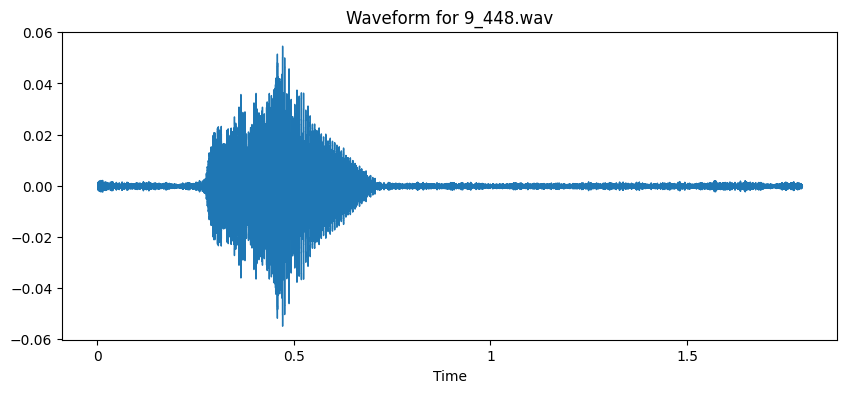

<Figure size 1000x400 with 0 Axes>

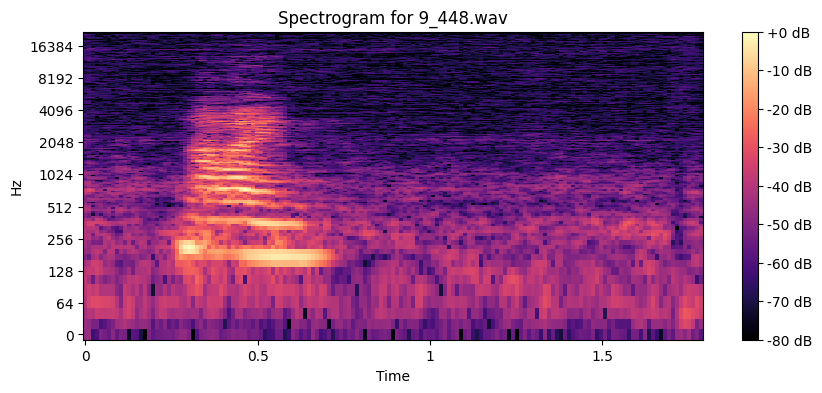

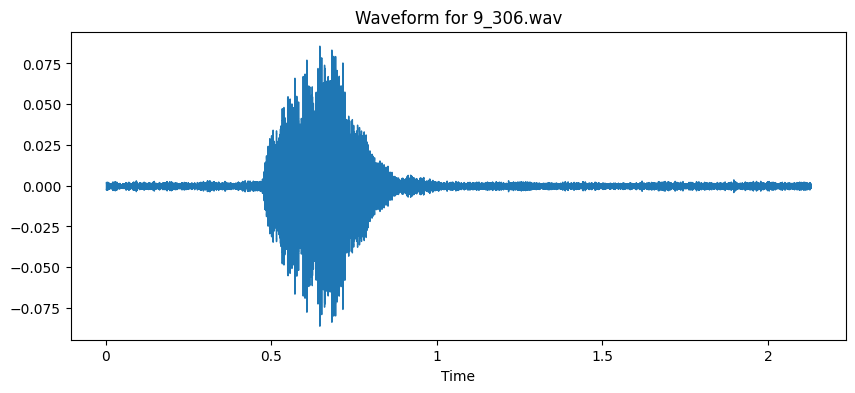

<Figure size 1000x400 with 0 Axes>

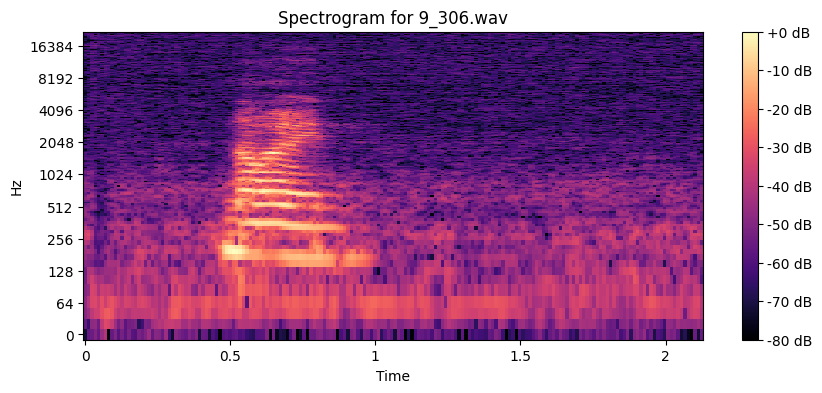

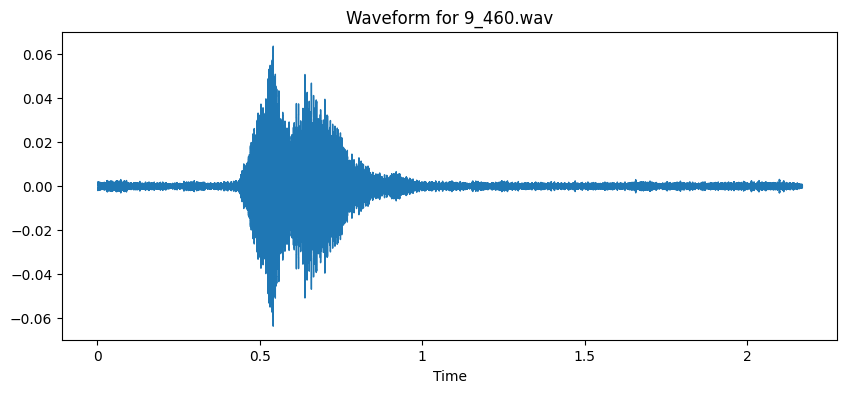

<Figure size 1000x400 with 0 Axes>

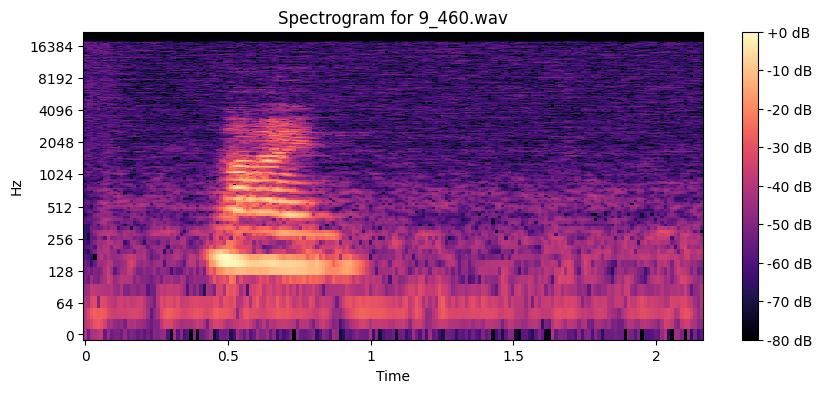

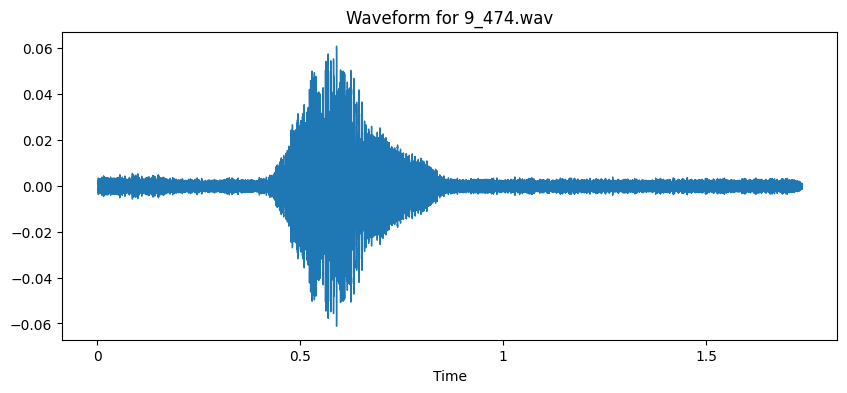

<Figure size 1000x400 with 0 Axes>

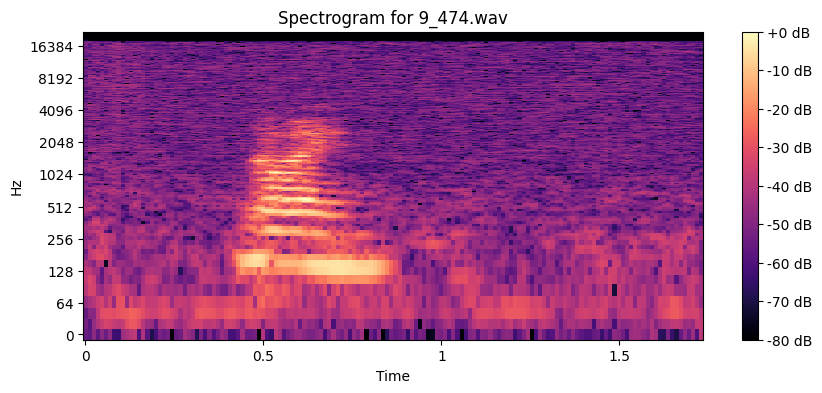

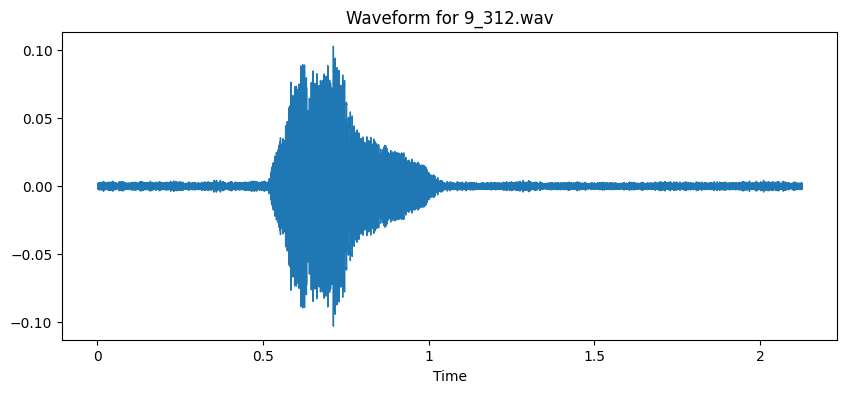

<Figure size 1000x400 with 0 Axes>

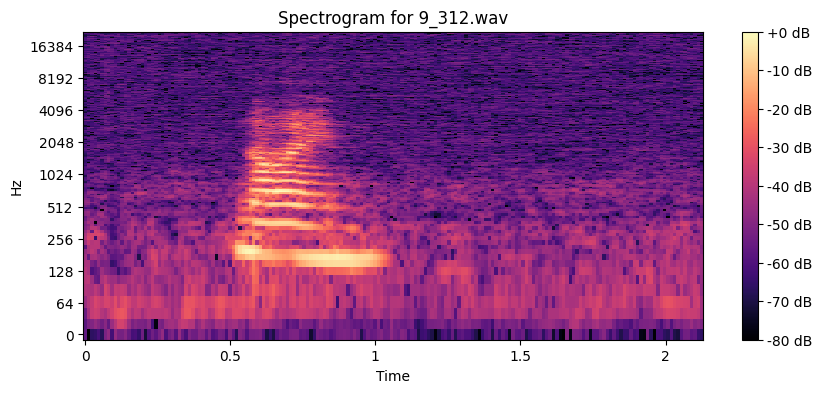

In [17]:
# display spectogramand audio player for all files in jo_digits/unprocessed
from IPython.display import Audio, display
import librosa
import matplotlib.pyplot as plt
import numpy as np
import os


# Define the directory for digit 0
#digit_dir = 'jo_digits/unprocessed'
digit_dir = 'processed'


# Get all files in the digit directory
files = glob.glob('processed/*/*')
print(files)

# Display spectogram and audio player for each file
for file in files[:5]:
    # Load the audio file
    y, sr = librosa.load(file, sr=None)
    
    # Display the spectogram
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f'Waveform for {os.path.basename(file)}')
    plt.show()
    
    # Display the spectogram
    plt.figure(figsize=(10, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram for {os.path.basename(file)}')
    plt.show()


    display(Audio(file))

In [1]:
# First pass: preprocess audio files so that they are all the same length

import glob
import librosa
import soundfile as sf
import numpy as np
from tqdm import tqdm

files = glob.glob('processed/*/*')
print(f"Total files: {len(files)}")

audio_data = []
labels = [] # here is where we create our labels
longest_audio_file_length = 0

# First pass: load data and find longest audio file
for f in tqdm(files):
    try:
        audio, sample_rate = librosa.load(f)
        if len(audio) == 0:
            print(f"Warning: Empty audio file: {f}")
            continue
        labels.append(int(f.split('/')[-2]))  # Adjust this based on your file structure
        longest_audio_file_length = max(longest_audio_file_length, len(audio))
    except Exception as e:
        print(f"Error processing file {f}: {str(e)}")

print(f"Longest audio size: {longest_audio_file_length}")


Total files: 10000


  0%|          | 0/10000 [00:00<?, ?it/s]/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/numba/cpython/hashing.py:477: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)
100%|██████████| 10000/10000 [00:27<00:00, 368.60it/s]

Longest audio size: 55124


In [2]:
# Second pass: Pad audio files and resave them
for f in tqdm(files):
    try:
        audio, sample_rate = librosa.load(f)
        if len(audio) == 0:
            print(f"Warning: Empty audio file: {f}")
            continue
        current_size = len(audio)
        pad_size = longest_audio_file_length - current_size
        left_pad = pad_size // 2
        right_pad = pad_size - left_pad
        padded_audio = np.pad(audio, (left_pad, right_pad), mode='constant')
        sf.write(f, padded_audio, sample_rate)
    except Exception as e:
        print(f"Error processing file {f}: {str(e)}")

100%|██████████| 10000/10000 [00:27<00:00, 364.44it/s]


In [3]:
# Third pass: Verify that all files have the same size
file_sizes = []
for f in tqdm(files):
    try:
        audio, _ = librosa.load(f)
        file_sizes.append(len(audio))
    except Exception as e:
        print(f"Error processing file {f}: {str(e)}")

if len(set(file_sizes)) == 1:
    print(f"All files have the same size: {file_sizes[0]} samples")
else:
    print("Warning: Not all files have the same size")
    print(f"Unique file sizes: {set(file_sizes)}")
    print(f"Min size: {min(file_sizes)}, Max size: {max(file_sizes)}")

100%|██████████| 10000/10000 [00:08<00:00, 1167.61it/s]

All files have the same size: 55124 samples


In [4]:
print(files[1000:1005])
print(labels[1000:1005])


['processed/0/0_729.wav', 'processed/0/0_715.wav', 'processed/0/0_701.wav', 'processed/0/0_932.wav', 'processed/0/0_926.wav']
[0, 0, 0, 0, 0]


## Part 4: Creating the Dataset and DataLoader

Now we convert our audio files into a format PyTorch can use for training.

### Key Concepts:

**Mel Spectrogram**: Instead of feeding raw audio waveforms to our model, we convert them to **mel spectrograms** - visual representations of sound that show frequency content over time. This is similar to how humans perceive sound!

**Dataset**: A PyTorch class that holds our data and knows how to load individual samples.

**DataLoader**: Handles batching (grouping samples together) and shuffling during training.

### Train/Validation/Test Split (Critical!)

- **Training set (70%)**: What the model learns from
- **Validation set (20%)**: Used to check for overfitting during training
- **Test set (10%)**: Held out completely - only used for final evaluation

**Avoiding Data Leakage**: All 10,000 augmented files come from just 10 original recordings. If we randomly split, variations of the same source end up in both train AND test - the model learns to recognize the specific recording rather than the digit!

**Our solution**: Split **proportionally within each digit**. For each digit's 1,000 files, the first 700 go to train, next 200 to validation, last 100 to test.

In [9]:
import torch as t
from torchaudio import transforms
import torchaudio
import random
from torch.utils.data import Dataset, DataLoader

# Custom Dataset class - tells PyTorch how to load our audio data
class AudioDataset(Dataset):
    def __init__(self, file_paths, labels, transforms=transforms.MelSpectrogram()):
        self.file_paths = file_paths  # List of paths to audio files
        self.labels = labels          # List of corresponding labels (0-9)
        self.transforms = transforms  # MelSpectrogram converts audio to spectrogram

    def __len__(self):
        """How many samples in the dataset?"""
        return len(self.file_paths)

    def __getitem__(self, idx):
        """Load and return a single sample (called by DataLoader)"""
        audio_path = self.file_paths[idx]
        waveform, _ = torchaudio.load(audio_path)

        # Ensure mono audio (single channel)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0).unsqueeze(0)

        # Convert waveform to mel spectrogram
        if self.transforms:
            spec = self.transforms(waveform)
        return spec, self.labels[idx]


# Split files BY DIGIT to avoid data leakage
# (Augmentations of the same source recording stay in the same set)
import glob

train_files, train_labels = [], []
val_files, val_labels = [], []
test_files, test_labels = [], []

for digit in range(10):
    # Get all files for this digit, sorted by name (keeps similar augmentations together)
    digit_files = sorted(glob.glob(f'processed/{digit}/*.wav'))
    n = len(digit_files)
    
    # Split: first 70% train, next 20% val, last 10% test
    train_end = int(0.7 * n)
    val_end = int(0.9 * n)
    
    train_files.extend(digit_files[:train_end])
    train_labels.extend([digit] * train_end)
    
    val_files.extend(digit_files[train_end:val_end])
    val_labels.extend([digit] * (val_end - train_end))
    
    test_files.extend(digit_files[val_end:])
    test_labels.extend([digit] * (n - val_end))

print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")
print(f"Test samples: {len(test_files)}")

# Create separate datasets for each split (no random_split needed!)
train_dataset = AudioDataset(train_files, train_labels, transforms=transforms.MelSpectrogram())
validation_dataset = AudioDataset(val_files, val_labels, transforms=transforms.MelSpectrogram())
test_dataset = AudioDataset(test_files, test_labels, transforms=transforms.MelSpectrogram())

# DataLoaders handle batching and shuffling
# batch_size=32 means we process 32 samples at a time
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=True)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(validation_loader)}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/

Training samples: 7000
Validation samples: 2000
Test samples: 1000
Number of training batches: 219
Number of validation batches: 63


/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [10]:
import matplotlib.pyplot as plt

# see a batch
for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(inputs[0][0].shape)
    print(targets)
    break


mel_freq_bins = inputs[0][0].shape[0]
time_steps = inputs[0][0].shape[1]

print("mel freq bins: ", mel_freq_bins)
print("time steps: ", time_steps)


torch.Size([32, 1, 128, 276])
torch.Size([128, 276])
tensor([7, 8, 6, 8, 8, 2, 0, 8, 1, 6, 4, 4, 2, 5, 0, 6, 5, 3, 4, 8, 9, 4, 9, 8,
        4, 3, 9, 1, 6, 5, 8, 6])
mel freq bins:  128
time steps:  276


In [11]:
# train with a simple Multi-Layer Perceptron (MLP) - Fully-Connected Neural Network

device = t.device('cuda' if t.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = t.nn.Sequential(
    t.nn.Flatten(),
    t.nn.Linear(mel_freq_bins*time_steps, 512), # 128 mel bins, 366 time steps
    t.nn.ReLU(),
    t.nn.Linear(512, 512),
    t.nn.ReLU(),
    t.nn.Linear(512, 10),
    t.nn.Softmax(dim=1)
)

# train our model
device = t.device('cuda' if t.cuda.is_available() else 'cpu')

model.to(device)

loss_fn = t.nn.CrossEntropyLoss()
optimizer = t.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

print(f"Training for {epochs} epochs")
for epoch in tqdm(range(epochs)):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

# evaluate our model

model.eval()

correct = 0
total = 0

with t.no_grad():
    for batch in validation_loader:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        _, predicted = t.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

print(f"Accuracy of the model on the test set: {100 * correct / total}%")

Using device: cpu
Training for 10 epochs


 10%|█         | 1/10 [00:43<06:27, 43.04s/it]

Epoch 1/10, Loss: 1.658427357673645


 20%|██        | 2/10 [01:18<05:08, 38.54s/it]

Epoch 2/10, Loss: 1.4617586135864258


...

Epoch 8/10, Loss: 1.4638763666152954


 90%|█████████ | 9/10 [05:39<00:38, 38.02s/it]

Epoch 9/10, Loss: 1.5028175115585327


100%|██████████| 10/10 [06:19<00:00, 37.96s/it]


Epoch 10/10, Loss: 1.4611625671386719
Accuracy of the model on the test set: 97.2%


### Understanding the MLP Above

The cell above trained a **Multi-Layer Perceptron (MLP)** - the simplest neural network architecture.

**How it works:**
1. **Flatten** the 2D spectrogram into a 1D vector (loses spatial structure)
2. Pass through **linear layers** that learn weights for each input
3. **ReLU activation** adds non-linearity: `output = max(0, input)`
4. Final layer outputs 10 values (one per digit)

**Training Loop:**
1. **Forward pass**: Feed data through the network to get predictions
2. **Calculate loss**: Measure how wrong the predictions are (CrossEntropyLoss)
3. **Backward pass**: Calculate gradients (how to adjust weights)
4. **Update weights**: Use optimizer (Adam) to improve the model

MLPs work, but they don't understand spatial relationships in the spectrogram. Let's try something better...

In [12]:
# Convolutional Neural Network for audio classification
import torch as t
import torch.nn as nn

# Use GPU if available (much faster training!)
device = t.device('cuda' if t.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class ConvModel(nn.Module):
    def __init__(self, mel_freq_bins, time_steps, num_classes=10):
        super(ConvModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Calculate the size of the flattened features (using explicit parameters)
        self.flat_features = 128 * (mel_freq_bins // 8) * (time_steps // 8)
        
        self.fc1 = nn.Linear(self.flat_features, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Input shape: (batch_size, 1, 128, 366)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = x.view(-1, self.flat_features) # rewrite this line with einops / ARENA
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

Using device: cpu


### Understanding the CNN Above

The cell above defined a **Convolutional Neural Network (CNN)** - designed for data with spatial structure like images and spectrograms.

**Key Components in ConvModel:**

| Layer | Purpose |
|-------|---------|
| `Conv2d` | Slides small filters across the input, detecting local patterns |
| `ReLU` | Activation function: `output = max(0, input)` |
| `MaxPool2d` | Reduces dimensions by keeping max value in each region |
| `Dropout` | Randomly disables neurons during training (prevents overfitting) |
| `Linear` | Fully connected layers for final classification |

**Architecture Flow:**
```
Spectrogram → [Conv→ReLU→Pool] x3 → Flatten → Linear → Linear → 10 digit scores
```

**Why CNNs beat MLPs:** Convolutions can detect patterns (like frequency bands) regardless of where they appear in the spectrogram. The pooling layers make the network robust to small shifts in timing.

In [13]:
# Initialize the model (passing mel_freq_bins and time_steps explicitly)

conv_model = ConvModel(mel_freq_bins=mel_freq_bins, time_steps=time_steps)
print(conv_model)

ConvModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=69632, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


Training for 15 epochs


  7%|▋         | 1/15 [03:39<51:17, 219.86s/it]

Epoch 1/15, Loss: 0.0017873059259727597


 13%|█▎        | 2/15 [07:16<47:11, 217.82s/it]

Epoch 2/15, Loss: 0.0016144152032211423


...

Epoch 13/15, Loss: 1.811885704228189e-05


 93%|█████████▎| 14/15 [47:00<03:12, 192.68s/it]

Epoch 14/15, Loss: 0.0


100%|██████████| 15/15 [50:25<00:00, 201.69s/it]


Epoch 15/15, Loss: 2.3313819838222116e-05
finished training


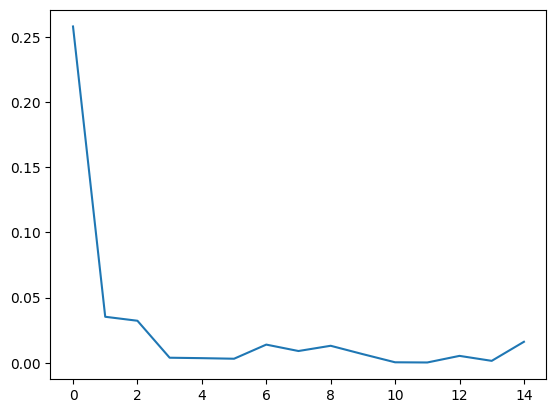

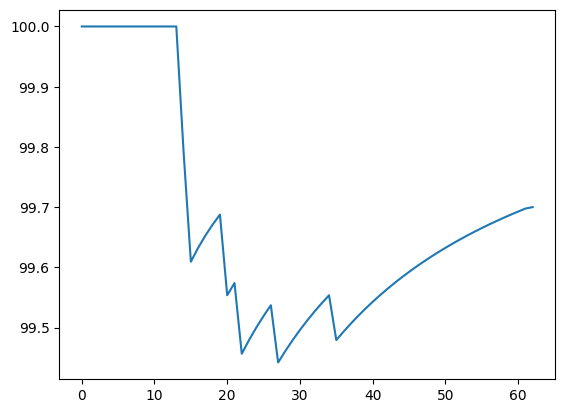

Accuracy of the conv model on the test set: 99.7%


In [14]:
# Train the model

conv_model = conv_model.to(device)

loss_fn = t.nn.CrossEntropyLoss()
optimizer = t.optim.Adam(conv_model.parameters(), lr=0.001)

epochs = 15

loss_history = []

print(f"Training for {epochs} epochs")
for epoch in tqdm(range(epochs)):
    conv_model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = conv_model(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

    loss_history.append(avg_loss)

print("finished training")

# plot the loss
plt.plot(loss_history)
plt.show()

# evaluate our model

conv_model.eval()
correct = 0
total = 0

# plot the accuracy
accuracy_history = []

with t.no_grad():
    for batch in validation_loader:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = conv_model(inputs)
        _, predicted = t.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        accuracy_history.append(100 * correct / total)

plt.plot(accuracy_history)
plt.show()

print(f"Accuracy of the conv model on the test set: {100 * correct / total}%")





### What Are Model Weights?

When we say we "trained" a neural network, we mean we adjusted millions of numbers (called **weights** or **parameters**) until the network could recognize patterns in our data.

The cell below shows you what these weights actually look like - just arrays of decimal numbers!

In [15]:
# Peek inside the model weights - what did the network actually learn?

print("=" * 60)
print("MODEL WEIGHTS - The numbers the network learned!")
print("=" * 60)

# Show all the layer names and their shapes
print("\nLayers in the model:\n")
for name, param in conv_model.named_parameters():
    print(f"  {name:30} shape: {str(list(param.shape)):20} ({param.numel():,} numbers)")

total_params = sum(p.numel() for p in conv_model.parameters())
print(f"\n  TOTAL: {total_params:,} learnable parameters!")

# Peek at actual values from the first conv layer
print("\n" + "=" * 60)
print("Zooming into conv1 weights (3x3 slice of the first filter):")
print("=" * 60)
conv1_weights = conv_model.conv1.weight.data[0, 0, :3, :3]  # First filter, 3x3 slice
print(conv1_weights)

print("\nThese numbers were RANDOM before training!")
print("Training adjusted them to recognize patterns in spectrograms.")

MODEL WEIGHTS - The numbers the network learned!

Layers in the model:

  conv1.weight                   shape: [32, 1, 3, 3]        (288 numbers)
  conv1.bias                     shape: [32]                 (32 numbers)
  conv2.weight                   shape: [64, 32, 3, 3]       (18,432 numbers)
  conv2.bias                     shape: [64]                 (64 numbers)
  conv3.weight                   shape: [128, 64, 3, 3]      (73,728 numbers)
  conv3.bias                     shape: [128]                (128 numbers)
  fc1.weight                     shape: [512, 69632]         (35,651,584 numbers)
  fc1.bias                       shape: [512]                (512 numbers)
  fc2.weight                     shape: [10, 512]            (5,120 numbers)
  fc2.bias                       shape: [10]                 (10 numbers)

  TOTAL: 35,749,898 learnable parameters!

Zooming into conv1 weights (3x3 slice of the first filter):
tensor([[-0.6067, -0.3294, -0.4260],
        [-0.6214, -0.6427

In [17]:
import os
# save the model with today's datetime
import datetime
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Create config dict with all parameters needed for inference
config = {
    # Model architecture parameters
    "mel_freq_bins": mel_freq_bins,
    "time_steps": time_steps,
    "num_classes": 10,
    
    # Audio preprocessing parameters (needed to recreate the same spectrogram shape)
    "sample_rate": 22050,  # librosa default
    "longest_audio_file_length": longest_audio_file_length,  # in samples
    
    # MelSpectrogram params (torchaudio defaults)
    "n_mels": 128,
    "n_fft": 400,
    "hop_length": 512,
}

# Extract the TRUE test set file paths (files the model never saw during training!)
# test_dataset is now a direct AudioDataset with file_paths and labels attributes
test_file_paths = test_dataset.file_paths
test_file_labels = test_dataset.labels

print(f"Saving {len(test_file_paths)} test set file paths (held out from training)")

# Save config, model weights, AND test set info
checkpoint = {
    "config": config,
    "model_state_dict": conv_model.state_dict(),
    "test_file_paths": test_file_paths,
    "test_file_labels": test_file_labels,
}

#make dir called model_weights
os.makedirs('model_weights', exist_ok=True) 
saved_model_path = f'model_weights/audrey_model_weights_{timestamp}.pth'

t.save(checkpoint, saved_model_path)
print(f"Saved model checkpoint to: {saved_model_path}")
print(f"(The inference cell will automatically use this path)")
print(f"Config: {config}")

Saving 1000 test set file paths (held out from training)
Saved model checkpoint to: model_weights/audrey_model_weights_2026-02-04_06-43-32.pth
(The inference cell will automatically use this path)
Config: {'mel_freq_bins': 128, 'time_steps': 276, 'num_classes': 10, 'sample_rate': 22050, 'longest_audio_file_length': 55124, 'n_mels': 128, 'n_fft': 400, 'hop_length': 512}


### What Did We Just Save?

The cell above created a **checkpoint** file containing:

- **Model weights**: The learned parameters (millions of numbers the network learned during training)
- **Config**: Architecture details (input dimensions, etc.) needed to reconstruct the model
- **Test set paths**: The exact files held out from training, for fair evaluation later

This checkpoint lets us load the trained model after restarting the notebook - no need to retrain!

---

## Part 9: Using the Trained Model

Everything below this point can be run **after restarting the notebook**. You just need to run the inference cell to load your trained model.

In [18]:
# ============================================================
# INFERENCE ONLY - Run this cell after restart to load model
# ============================================================
# This cell is self-contained and can be run after clearing 
# all variables or restarting the notebook kernel.

import torch as t
import torch.nn as nn
from torchaudio import transforms
import torchaudio

# 1. Define the model architecture (must match training)
class ConvModel(nn.Module):
    def __init__(self, mel_freq_bins, time_steps, num_classes=10):
        super(ConvModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flat_features = 128 * (mel_freq_bins // 8) * (time_steps // 8)
        
        self.fc1 = nn.Linear(self.flat_features, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = x.view(-1, self.flat_features)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 2. Load checkpoint (contains both config and weights)
device = t.device('cuda' if t.cuda.is_available() else 'cpu')
# Use the path from the save cell if available, otherwise specify manually
if 'saved_model_path' not in dir():
    # Update this path if running after kernel restart
    saved_model_path = 'model_weights/audrey_model_weights_2026-02-01_18-00-30.pth'
print(f"Loading model from: {saved_model_path}")

checkpoint = t.load(saved_model_path, map_location=device)
config = checkpoint['config']

print(f"Loaded config: {config}")

# Load the true test set (files the model never saw during training)
test_file_paths = checkpoint.get('test_file_paths', [])
test_file_labels = checkpoint.get('test_file_labels', [])
print(f"Loaded {len(test_file_paths)} held-out test files")

# 3. Initialize model with saved config and load weights
model = ConvModel(
    mel_freq_bins=config['mel_freq_bins'],
    time_steps=config['time_steps'],
    num_classes=config['num_classes']
)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# 4. Define preprocessing function
def preprocess_audio(audio_path, config):
    """Load and preprocess audio to match training data shape."""
    waveform, sr = torchaudio.load(audio_path)
    
    # Resample to match training sample rate (librosa default is 22050)
    target_sr = config['sample_rate']  # 22050
    if sr != target_sr:
        resampler = transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
    
    # Ensure mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0).unsqueeze(0)
    
    # Pad or truncate to match training audio length
    target_length = config['longest_audio_file_length']
    current_length = waveform.shape[1]
    
    if current_length < target_length:
        # Pad (center padding like training)
        pad_size = target_length - current_length
        left_pad = pad_size // 2
        right_pad = pad_size - left_pad
        waveform = t.nn.functional.pad(waveform, (left_pad, right_pad))
    elif current_length > target_length:
        # Truncate (center crop)
        start = (current_length - target_length) // 2
        waveform = waveform[:, start:start + target_length]
    
    # Use default MelSpectrogram (matches AudioDataset training setup)
    mel_transform = transforms.MelSpectrogram()
    spec = mel_transform(waveform)
    
    return spec.unsqueeze(0)  # Add batch dimension

# 5. Define prediction function
def predict_digit(audio_path):
    """Predict the digit from an audio file."""
    spec = preprocess_audio(audio_path, config).to(device)
    
    with t.no_grad():
        output = model(spec)
        predicted = t.argmax(output, dim=1).item()
        confidence = t.softmax(output, dim=1)[0, predicted].item()
    
    return predicted, confidence

print(f"Model loaded successfully! Ready for inference.")
print(f"Use predict_digit('path/to/audio.wav') to make predictions.")

Loading model from: model_weights/audrey_model_weights_2026-02-04_06-43-32.pth
Loaded config: {'mel_freq_bins': 128, 'time_steps': 276, 'num_classes': 10, 'sample_rate': 22050, 'longest_audio_file_length': 55124, 'n_mels': 128, 'n_fft': 400, 'hop_length': 512}
Loaded 1000 held-out test files
Model loaded successfully! Ready for inference.
Use predict_digit('path/to/audio.wav') to make predictions.


### Understanding the Inference Cell Above

The large cell above is **self-contained** - it can be run after restarting the notebook to load your trained model. It includes:

1. **Model architecture** (must match what was trained)
2. **Checkpoint loading** (weights + config)
3. **`preprocess_audio()`** - Prepares new audio to match training format
4. **`predict_digit()`** - Takes an audio file path, returns predicted digit

**Why preprocessing matters:** The model expects input in a very specific format (sample rate, length, spectrogram shape). If we preprocess differently than during training, the model will fail!

## Part 10: Evaluating Model Performance

### Why Test Sets Matter

The cells below demonstrate a critical ML concept: **proper evaluation**.

| Test Type | What It Tests | Potential Issue |
|-----------|---------------|-----------------|
| **True Test Set** | Files NEVER seen during training | Fair evaluation |
| **Random Files** | Any files from `processed/` | May include training data! |

**Overfitting** happens when a model memorizes training examples instead of learning general patterns. Signs of overfitting:
- High accuracy on training data
- Lower accuracy on truly new data (test set)

If random files show much higher accuracy than the true test set, your model is overfitting!

In [19]:
# Test on the TRUE HELD-OUT TEST SET (model never saw these during training!)
import random

if not test_file_paths:
    print("No test set found in checkpoint. Re-run training with the updated save cell.")
else:
    # Test on a sample of the held-out test set
    num_tests = min(20, len(test_file_paths))
    test_indices = random.sample(range(len(test_file_paths)), num_tests)
    correct = 0
    
    print(f"Testing on {num_tests} files from the TRUE HELD-OUT TEST SET")
    print(f"(Total held-out files: {len(test_file_paths)})")
    print("=" * 50)
    print("These files were NEVER seen during training!\n")
    
    for i, idx in enumerate(test_indices):
        test_file = test_file_paths[idx]
        true_label = test_file_labels[idx]
        predicted_digit, confidence = predict_digit(test_file)
        
        is_correct = predicted_digit == true_label
        correct += is_correct
        
        status = "correct" if is_correct else "WRONG"
        print(f"{i+1}. True={true_label}, Pred={predicted_digit}, Conf={confidence:.1%} [{status}]")
    
    print("=" * 50)
    print(f"TRUE TEST SET Accuracy: {correct}/{num_tests} = {100*correct/num_tests:.1f}%")

Testing on 20 files from the TRUE HELD-OUT TEST SET
(Total held-out files: 1000)
These files were NEVER seen during training!

1. True=4, Pred=4, Conf=100.0% [correct]
2. True=6, Pred=6, Conf=100.0% [correct]
3. True=9, Pred=9, Conf=100.0% [correct]
4. True=6, Pred=6, Conf=100.0% [correct]
5. True=9, Pred=9, Conf=100.0% [correct]
6. True=4, Pred=4, Conf=100.0% [correct]
7. True=5, Pred=5, Conf=100.0% [correct]


/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


8. True=1, Pred=1, Conf=100.0% [correct]
9. True=3, Pred=3, Conf=100.0% [correct]
10. True=6, Pred=6, Conf=100.0% [correct]
11. True=3, Pred=3, Conf=100.0% [correct]
12. True=7, Pred=7, Conf=100.0% [correct]
13. True=7, Pred=7, Conf=100.0% [correct]
14. True=1, Pred=1, Conf=100.0% [correct]
15. True=3, Pred=3, Conf=100.0% [correct]
16. True=3, Pred=3, Conf=100.0% [correct]
17. True=8, Pred=8, Conf=100.0% [correct]
18. True=6, Pred=6, Conf=100.0% [correct]
19. True=4, Pred=4, Conf=100.0% [correct]
20. True=1, Pred=1, Conf=100.0% [correct]
TRUE TEST SET Accuracy: 20/20 = 100.0%


In [20]:
# Test inference with a random file from the processed dataset
# (Works after kernel restart - just needs the inference cell to be run first)
import random
import glob

# Get all processed audio files
processed_files = glob.glob('processed/*/*')
print(f"Found {len(processed_files)} files in processed/")

# Pick a random file
test_file = random.choice(processed_files)

# Extract true label from folder name (e.g., "processed/3/3_123.wav" -> 3)
true_label = int(test_file.split('/')[-2])

# Make prediction
predicted_digit, confidence = predict_digit(test_file)

print(f"\nTest file: {test_file}")
print(f"True label: {true_label}")
print(f"Predicted: {predicted_digit}")
print(f"Confidence: {confidence:.2%}")
print(f"Correct: {'Yes' if predicted_digit == true_label else 'No'}")

Found 10000 files in processed/

Test file: processed/7/7_46.wav
True label: 7
Predicted: 7
Confidence: 100.00%
Correct: Yes


In [21]:
# Test on RANDOM files from processed/ (MAY INCLUDE TRAINING DATA!)
# Compare this accuracy to the true test set above to see if the model is overfitting
import random
import glob

processed_files = glob.glob('processed/*/*')
num_tests = min(20, len(processed_files))
correct = 0

# Get random files
test_files = random.sample(processed_files, num_tests)

print(f"Testing on {num_tests} RANDOM files from processed/")
print("=" * 50)
print("WARNING: Some of these may have been in the training set!\n")

for i, test_file in enumerate(test_files):
    true_label = int(test_file.split('/')[-2])
    predicted_digit, confidence = predict_digit(test_file)
    
    is_correct = predicted_digit == true_label
    correct += is_correct
    
    status = "correct" if is_correct else "WRONG"
    print(f"{i+1}. True={true_label}, Pred={predicted_digit}, Conf={confidence:.1%} [{status}]")

print("=" * 50)
print(f"RANDOM FILES Accuracy: {correct}/{num_tests} = {100*correct/num_tests:.1f}%")
print("\nCompare this to the TRUE TEST SET accuracy above!")

Testing on 20 RANDOM files from processed/

1. True=6, Pred=6, Conf=100.0% [correct]
2. True=6, Pred=6, Conf=100.0% [correct]
3. True=5, Pred=5, Conf=100.0% [correct]
4. True=1, Pred=1, Conf=100.0% [correct]
5. True=1, Pred=1, Conf=100.0% [correct]
6. True=2, Pred=2, Conf=100.0% [correct]
7. True=9, Pred=9, Conf=100.0% [correct]
8. True=8, Pred=8, Conf=100.0% [correct]
9. True=7, Pred=7, Conf=100.0% [correct]
10. True=4, Pred=4, Conf=100.0% [correct]
11. True=4, Pred=4, Conf=100.0% [correct]
12. True=3, Pred=3, Conf=100.0% [correct]
13. True=3, Pred=3, Conf=100.0% [correct]
14. True=0, Pred=0, Conf=100.0% [correct]
15. True=6, Pred=6, Conf=100.0% [correct]
16. True=7, Pred=7, Conf=100.0% [correct]
17. True=1, Pred=1, Conf=100.0% [correct]
18. True=1, Pred=1, Conf=100.0% [correct]
19. True=8, Pred=8, Conf=100.0% [correct]
20. True=0, Pred=0, Conf=100.0% [correct]
RANDOM FILES Accuracy: 20/20 = 100.0%

Compare this to the TRUE TEST SET accuracy above!


In [22]:
# Test on 10 random files from the processed dataset
import glob
import random

processed_files = glob.glob('processed/*/*')
print(f"Found {len(processed_files)} files in processed/\n")

num_tests = 10
test_files = random.sample(processed_files, num_tests)
correct = 0

for i, test_file in enumerate(test_files):
    true_label = int(test_file.split('/')[-2])
    predicted_digit, confidence = predict_digit(test_file)
    
    is_correct = predicted_digit == true_label
    correct += is_correct
    
    status = "correct" if is_correct else "WRONG"
    print(f"{i+1}. {test_file.split('/')[-1]}: True={true_label}, Pred={predicted_digit}, Conf={confidence:.1%} [{status}]")

print(f"\nAccuracy: {correct}/{num_tests} = {100*correct/num_tests:.1f}%")

Found 10000 files in processed/

1. 5_324.wav: True=5, Pred=5, Conf=100.0% [correct]
2. 2_795.wav: True=2, Pred=2, Conf=100.0% [correct]
3. 5_657.wav: True=5, Pred=5, Conf=100.0% [correct]
4. 2_33.wav: True=2, Pred=2, Conf=100.0% [correct]
5. 7_651.wav: True=7, Pred=7, Conf=100.0% [correct]
6. 8_753.wav: True=8, Pred=8, Conf=100.0% [correct]
7. 8_14.wav: True=8, Pred=8, Conf=100.0% [correct]
8. 2_462.wav: True=2, Pred=2, Conf=100.0% [correct]
9. 5_637.wav: True=5, Pred=5, Conf=100.0% [correct]
10. 4_813.wav: True=4, Pred=4, Conf=100.0% [correct]

Accuracy: 10/10 = 100.0%


In [23]:
# Test on ALL original recordings from the unprocessed dataset
import glob

unprocessed_files = sorted(glob.glob('unprocessed/*.wav'))
print(f"Found {len(unprocessed_files)} original recordings in unprocessed/\n")

correct = 0

for test_file in unprocessed_files:
    # Extract true label from filename (e.g., "0.wav" -> 0)
    true_label = int(test_file.split('/')[-1].split('.')[0])
    predicted_digit, confidence = predict_digit(test_file)
    
    is_correct = predicted_digit == true_label
    correct += is_correct
    
    status = "correct" if is_correct else "WRONG"
    print(f"{test_file}: True={true_label}, Pred={predicted_digit}, Conf={confidence:.1%} [{status}]")

print(f"\nAccuracy on original recordings: {correct}/{len(unprocessed_files)} = {100*correct/len(unprocessed_files):.1f}%")

Found 10 original recordings in unprocessed/

unprocessed/0.wav: True=0, Pred=0, Conf=100.0% [correct]
unprocessed/1.wav: True=1, Pred=1, Conf=100.0% [correct]
unprocessed/2.wav: True=2, Pred=2, Conf=100.0% [correct]
unprocessed/3.wav: True=3, Pred=3, Conf=100.0% [correct]
unprocessed/4.wav: True=4, Pred=4, Conf=100.0% [correct]
unprocessed/5.wav: True=5, Pred=5, Conf=100.0% [correct]
unprocessed/6.wav: True=6, Pred=6, Conf=100.0% [correct]
unprocessed/7.wav: True=7, Pred=7, Conf=100.0% [correct]
unprocessed/8.wav: True=8, Pred=8, Conf=100.0% [correct]
unprocessed/9.wav: True=9, Pred=9, Conf=100.0% [correct]

Accuracy on original recordings: 10/10 = 100.0%


## Part 11: Real-time Digit Recognition

Now for the fun part - using your trained model in real-time!

The cell below implements **Voice Activity Detection (VAD)** to:
1. Listen continuously for sound above a threshold
2. Start recording when you speak
3. Stop when you go silent
4. Run inference and display the prediction
5. Return to listening

**Tunable parameters:**
- `VOLUME_THRESHOLD`: RMS level to trigger recording (increase if noisy)
- `SILENCE_DURATION`: Seconds of silence before stopping
- `MIN/MAX_RECORDING_DURATION`: Recording length bounds

**Requirements:** Run the inference cell first to load the model!

In [24]:
# Real-time digit recognition with voice activity detection (VAD)
# Requires the inference cell (cell 18) to be run first!

import sounddevice as sd
import numpy as np
import torch as t
from torchaudio import transforms
from IPython.display import clear_output

# Config
SAMPLE_RATE = 44100  # Recording sample rate
TARGET_SAMPLE_RATE = 22050  # Model expects this (librosa default)
BLOCK_SIZE = 1024  # Samples per callback

# Voice Activity Detection settings
# ADJUST THESE FOR YOUR ENVIRONMENT:
VOLUME_THRESHOLD = 0.05  # RMS threshold to detect speech (increase in noisy rooms: 0.05-0.1)
SILENCE_DURATION = 0.4   # Seconds of silence before stopping (shorter = more responsive)
MIN_RECORDING_DURATION = 0.5  # Minimum seconds to record (increase to capture full digit)
MAX_RECORDING_DURATION = 2.5  # Maximum seconds to record (match original training duration)

# State variables
audio_buffer = []
is_recording = False
silence_samples = 0
silence_samples_threshold = int(SILENCE_DURATION * SAMPLE_RATE / BLOCK_SIZE)
min_samples = int(MIN_RECORDING_DURATION * SAMPLE_RATE)
max_samples = int(MAX_RECORDING_DURATION * SAMPLE_RATE)

def process_and_predict(audio_data):
    """Process accumulated audio and run prediction."""
    # Normalize audio (peak normalization to match training data levels)
    audio_data = audio_data / (np.max(np.abs(audio_data)) + 1e-8)
    audio_data = audio_data * 0.9  # Scale to ~90% to avoid clipping
    
    # Convert to tensor
    waveform = t.tensor(audio_data, dtype=t.float32).unsqueeze(0)
    
    # Resample to match training
    resampler = transforms.Resample(orig_freq=SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    waveform = resampler(waveform)
    
    # Pad or truncate to match training audio length
    target_length = config['longest_audio_file_length']
    current_length = waveform.shape[1]
    
    if current_length < target_length:
        pad_size = target_length - current_length
        left_pad = pad_size // 2
        right_pad = pad_size - left_pad
        waveform = t.nn.functional.pad(waveform, (left_pad, right_pad))
    elif current_length > target_length:
        start = (current_length - target_length) // 2
        waveform = waveform[:, start:start + target_length]
    
    # Compute mel spectrogram (using defaults to match training)
    mel_transform = transforms.MelSpectrogram()
    spec = mel_transform(waveform).unsqueeze(0).to(device)
    
    # Run inference
    with t.no_grad():
        output = model(spec)
        predicted = t.argmax(output, dim=1).item()
        confidence = t.softmax(output, dim=1)[0, predicted].item()
    
    return predicted, confidence

def audio_callback(indata, frames, time_info, status):
    """Called for each block of audio from the microphone."""
    global audio_buffer, is_recording, silence_samples
    
    if status:
        print(f"Status: {status}")
    
    # Calculate RMS volume for this block
    audio_block = indata[:, 0]
    rms = np.sqrt(np.mean(audio_block**2))
    
    if not is_recording:
        # Waiting for speech to start
        if rms > VOLUME_THRESHOLD:
            is_recording = True
            silence_samples = 0
            audio_buffer = list(audio_block)  # Start with this block
            clear_output(wait=True)
            print("Recording... (speak your digit)")
    else:
        # Currently recording
        audio_buffer.extend(audio_block.tolist())
        
        if rms < VOLUME_THRESHOLD:
            silence_samples += 1
        else:
            silence_samples = 0  # Reset silence counter if sound detected
        
        # Check if we should stop recording
        should_stop = False
        
        if len(audio_buffer) >= max_samples:
            should_stop = True  # Hit max duration
        elif silence_samples >= silence_samples_threshold and len(audio_buffer) >= min_samples:
            should_stop = True  # Silence detected after minimum recording
        
        if should_stop:
            # Process the recording
            audio_data = np.array(audio_buffer)
            duration = len(audio_data) / SAMPLE_RATE
            
            predicted, confidence = process_and_predict(audio_data)
            
            clear_output(wait=True)
            print("=" * 40)
            print(f"  Predicted Digit:  {predicted}")
            print(f"  Confidence:       {confidence:.1%}")
            print(f"  Audio duration:   {duration:.2f}s")
            print("=" * 40)
            print(f"\nListening... (speak a digit to start)")
            
            # Reset state
            audio_buffer = []
            is_recording = False
            silence_samples = 0

# Start listening
print("Real-time Digit Recognition (Voice Activated)")
print("=" * 40)
print(f"Volume threshold: {VOLUME_THRESHOLD} RMS")
print(f"Silence timeout:  {SILENCE_DURATION}s")
print(f"Max recording:    {MAX_RECORDING_DURATION}s")
print("=" * 40)
print("\nListening... (speak a digit to start)")
print("\n>>> Click the STOP button (square) or press 'i' twice to stop <<<")

stream = None
try:
    stream = sd.InputStream(
        samplerate=SAMPLE_RATE,
        blocksize=BLOCK_SIZE,
        channels=1,
        callback=audio_callback
    )
    stream.start()
    
    # Loop with short sleeps - much easier to interrupt
    while True:
        sd.sleep(100)  # 100ms intervals - responsive to interrupts
        
except KeyboardInterrupt:
    pass
finally:
    if stream is not None:
        stream.stop()
        stream.close()
    audio_buffer = []
    is_recording = False
    silence_samples = 0
    print("\nStopped!")

  Predicted Digit:  3
  Confidence:       100.0%
  Audio duration:   0.51s

Listening... (speak a digit to start)

Stopped!


## Exercises and Next Steps

Now that you've built your own Audrey, try these challenges:

### Exploration
1. **Test robustness**: What happens if you say a digit in a different accent or tone?
2. **Out-of-vocabulary**: What does the model predict when you say a word that isn't a digit?
3. **Different device**: Play a digit from your phone speaker - does it still work?

### Extensions
4. **New vocabulary**: Train on different sounds (you might need to change how the files get saved and processed in the dataset creation step):
   - Yes / No
   - Colors (red, blue, green...)
   - Letters (A, B, C...)
   - Environmental sounds (clap, snap, whistle...)
   
5. **Improve the model**: 
   - Record more original samples
   - Adjust augmentation parameters
   - Try different network architectures

6. **Investigate bias**: 
   - Train on recordings from multiple people
   - Test in different acoustic environments
   - What makes a "fair" speech recognition dataset?

---

## Summary

In this notebook you learned:
- **Data collection** and the importance of representative training data
- **Data augmentation** to create variations and improve robustness
- **Neural network architectures**: MLP vs CNN for audio classification
- **Training loop**: forward pass → loss → backpropagation → optimization
- **Evaluation**: Why held-out test sets matter
- **Inference**: Using trained models on new data
- **Dataset bias**: How recording conditions affect model performance

Congratulations - you've built a speech recognition system from scratch!